In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from  tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import numpy as np

In [2]:
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
max_length = 200

X_train = pad_sequences(X_train, maxlen = max_length)
X_test = pad_sequences(X_test, maxlen = max_length)

In [4]:
model = Sequential()
model.add(Embedding(vocab_size, 16, input_length=max_length))
model.add(GlobalAveragePooling1D())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [7]:
history = model.fit(X_train, y_train, epochs=10, batch_size=512, validation_split=0.2,verbose=1)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.6039 - loss: 0.6874 - val_accuracy: 0.7406 - val_loss: 0.6772
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7120 - loss: 0.6635 - val_accuracy: 0.7304 - val_loss: 0.6425
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7733 - loss: 0.6157 - val_accuracy: 0.7776 - val_loss: 0.5822
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8103 - loss: 0.5461 - val_accuracy: 0.8052 - val_loss: 0.5122
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8342 - loss: 0.4731 - val_accuracy: 0.8354 - val_loss: 0.4499
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8490 - loss: 0.4142 - val_accuracy: 0.8478 - val_loss: 0.4034
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8668 - loss: 0.3679 - val_accuracy: 0.8548 - val_loss: 0.3718
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8755 - loss: 0.3351 - val_accuracy: 0.8442 - v

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8656 - loss: 0.3261
Test Loss: 0.3261451721191406
Test Accuracy: 0.8656399846076965


In [10]:
predictions = model.predict(X_test)

for i in range(10):
  sentiment = "Positive" if predictions[i][0] > 0.5 else "Negative"
  print("Prediction:",sentiment," Actual:",y_test[i])

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Prediction: Negative  Actual: 0
Prediction: Positive  Actual: 1
Prediction: Positive  Actual: 1
Prediction: Positive  Actual: 0
Prediction: Positive  Actual: 1
Prediction: Positive  Actual: 1
Prediction: Positive  Actual: 1
Prediction: Negative  Actual: 0
Prediction: Positive  Actual: 0
Prediction: Positive  Actual: 1


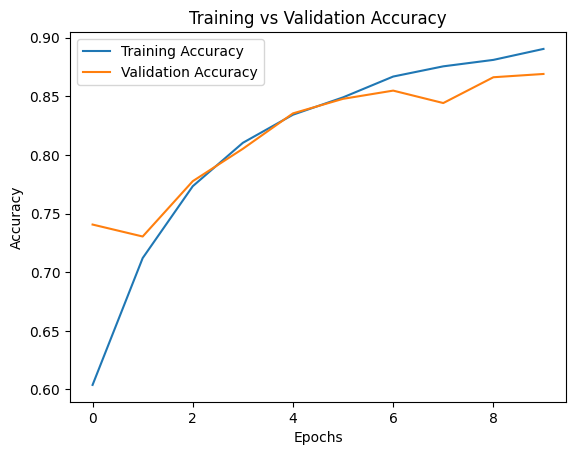

In [11]:
plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()